# Weekly Homework 1: Fuel Economy

### Author: Elias Nicolas


## Introduction to Machine Learning

#### University of Redlands - DATA 301
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website](https://joannabieri.com/machine_learning.html)

---

**Due Sunday 9/6 at 11:59pm.** This covers Day 1 and Day 2.

GOALS:

1. Dust off your DATA 101 skills on a real, slightly messy dataset.
2. Do a train/test split properly, and understand why it comes early.
3. Use everything from Day 2: polynomial features, RMSE, underfitting and overfitting.
4. Say what your numbers actually mean.

**How to turn this in.** In your own repository:

```bash
git checkout -b hw/week-01
git add .
git commit -m "Weekly homework 1"
git push origin hw/week-01
```

Then open a Pull Request into `main`. That Pull Request is your submission.

**What I am grading.** Working code with no writing is not a pass. Every question that asks "why" or "what does this mean" needs real sentences. That is the part I actually care about.

This is a full mini project, so unlike the daily notes there are no optional parts here. Answer everything, in order. Several questions ask you to commit to a guess before you run the code, and those are there on purpose, so do not skip ahead and backfill them.

## The data

We are using the `mpg` dataset: 398 cars from the 1970s and early 80s with their fuel economy in miles per gallon. It is real data, which means it has some problems in it. Good.

**The question:** can we predict a car's fuel economy from its horsepower?

# Part 1: Get to know the data

This part is DATA 101 review. You should be able to do all of it already.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cars = sns.load_dataset("mpg")
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


**1a.** How many rows and columns? What does a single row represent in the real world?

**1b.** Print the column names and their data types. Which are numeric and which are not?

**1c.** Run `.describe()`. Pick two columns and say in words what their ranges tell you about these cars.

In [2]:
rows = cars.shape[0]
cols = cars.shape[1]

print(f'There are {rows} rows in the dataset')
print(f'There are {cols} columns in the dataset')

There are 398 rows in the dataset
There are 9 columns in the dataset


In [3]:
cars.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

In [4]:
cars.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


*A single row represents a car model along with the data associated with it in the real world.*

*Origin and name are not numeric while the rest of the columns are numerical data types.* 

*The range for the weight column tells me that this dataset has a wide variety of different car makes, as some way more than others exponentially. The acceleration column of the dataset also has a wide range, this leads me to assume that different car models have more powerful engines thus allowing for faster acceleration compared to other cars.*

---

## Missing data

**1d.** Check for missing values. Which column has them, and how many?

**1e.** Print the actual rows that are missing something.

**1f.** Decide what to do about them: drop, fill, or keep. **Do it, and defend it in two or three sentences.** There is no single right answer, but there is a wrong one, which is doing something without saying why.

In [5]:
cars.shape

(398, 9)

In [6]:
cars_2 = cars[cars.isna().any(axis=1)]
cars_2.reset_index()

,index,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
1,126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
2,330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
3,336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
4,354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
5,374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


In [7]:
cars = cars.dropna(axis=0, how ='any')
cars.shape ##It dropped from 398 to 392, proof that it works

(392, 9)

*I chose to drop these rows with a NaN values because if I fill them with zeros as placeholder values than it would provide an inacurate representation of my data. On the other hand if I keep the NaN values as is I believe it is also not representing the data correctly, as the car models do have a horsepower they operate at it is just unkown in the dataset. So, the best way to deal with this (to my knowledge) was to get rid of the rows with a NaN value.*

---

**1g.** Before you write any more code, write down what you expect the relationship between **horsepower** and **mpg** to look like. Going up? Down? Straight? Curved?

You will check this in Part 3. Being wrong is fine and interesting, and I would rather see a wrong guess than no guess.

*I expect there to be a indirect (Down) correlation between horsepower and mpg, as the more horsepower needed means more gallons of gasoline used thus reducing the total mpg.*

---

# Part 2: Split before you look too hard

Here is what is new since DATA 101.

We are about to explore this data, plot it, and get ideas from it. Every one of those ideas is a decision. If we make those decisions while looking at **all** the data, we have quietly used the test set to build the model, and then it is not a fair test any more.

So we split **now**, before the interesting exploration, and from here on we only look at the training set.

In [8]:
from sklearn.model_selection import train_test_split

df = cars.copy()
X = df[['horsepower']]
y = df[['mpg']] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size=0.2) 

In [9]:
X.shape

(392, 1)

In [10]:
X_train.shape

(313, 1)

In [11]:
X_test.shape

(79, 1)

In [12]:
y.shape

(392, 1)

In [13]:
y_train.shape

(313, 1)

In [14]:
y_test.shape

(79, 1)

**2a.** How many rows in each set?

**2b.** Why `random_state=42`? What would happen if you left it out and reran the notebook a few times?

**2c.** In your own words, why did we split *before* exploring rather than after?

*There are 313 rows in the training set and 79 rows in the testing set.*

*If you left out 'random_state=42', than the results would not be reproducible and after you run the notebook a few times the results would be drastically different than the original test run*

*We split before exploring rather than after because we want to ensure that our model works on unseen data*

---

# Part 3: Explore the training set

Now look properly. **Training set only.**

**3a.** Scatter plot `horsepower` against `mpg`. Compare it to what you predicted in 1g. Were you right?

**3b.** Is this a straight line relationship? Say what you see.

**3c.** Make one more plot of your own choosing and say what it tells you.

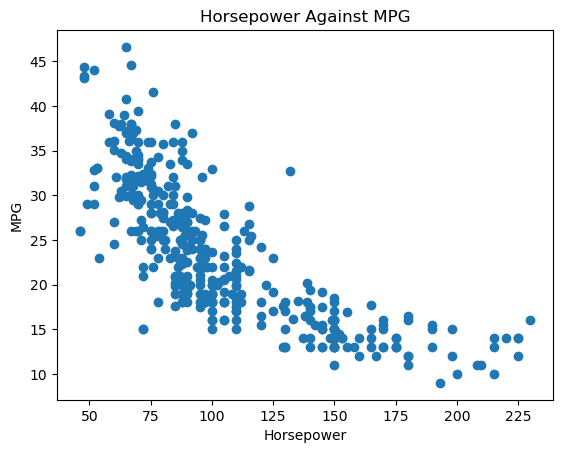

In [15]:
plt.scatter(X, y) 
plt.title('Horsepower Against MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()

In [16]:
## Need to Make own plot

*Yes, my initial assumption of the 'Down' relationship between horsepower and mpg was correct.*

*No, this is not a linear relationship shown from the plot, I infer its more of a negative parabolic function.*

---

# Part 4: Fit some models

Training set only.

**4a.** Fit a straight line and plot it on the training data.

**4b.** Report the training RMSE. What are the **units** of that number? A student says "the RMSE is 4.9." What does that mean about a car?

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train) 

LinearRegression()

In [18]:
X_new = np.linspace(X.min(), X.max() , 100).reshape(-1, 1)
y_pred = lin_reg.predict(X_new)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


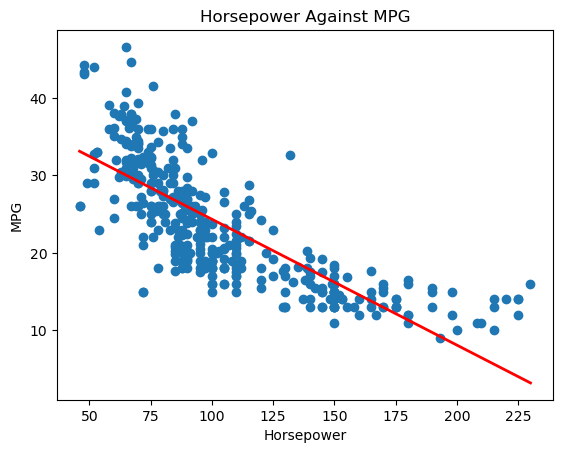

In [19]:
plt.scatter(X, y) 
plt.plot(X_new, y_pred, "r-", linewidth=2, label="straight line")
plt.title('Horsepower Against MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()

In [20]:
from sklearn.metrics import root_mean_squared_error

y_predicted = lin_reg.predict(X)
rmse = root_mean_squared_error(y, y_predicted)

print(f'RMSE: {round(rmse, 5 )}')

RMSE: 4.89972


*Your answers here.*

---

**4c.** Fit polynomial models of degree 2, 5, and 15. Plot them all on one figure with the training data.

**4d.** Make a small table of training RMSE for each degree, including the straight line.

**4e.** Look at your table. **Is degree 15 much better than degree 2?** Say what you expected and what actually happened.

*Your answers here.*

---

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


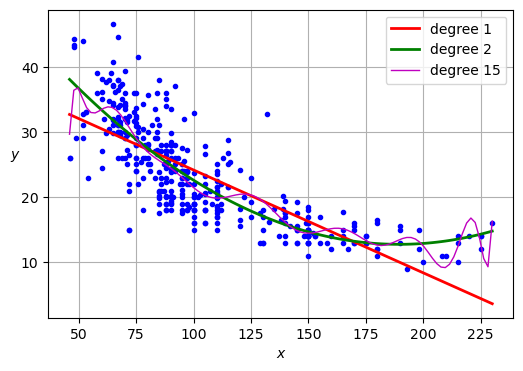

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")

for degree, style, width in [(1, "r-", 2), (2, "g-", 2), (15, "m-", 1)]:

    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_poly)

    lin_reg = LinearRegression()
    lin_reg.fit(X_scaled, y)

    X_new_poly = poly_features.transform(X_new)
    X_new_scaled = scaler.transform(X_new_poly)
    y_pred = lin_reg.predict(X_new_scaled)

    plt.plot(X_new, y_pred, style, linewidth=width, label=f"degree {degree}")

plt.xlabel("$x$"); plt.ylabel("$y$", rotation=0)
plt.legend(); plt.grid()
plt.show()

In [43]:
degrees = [1, 2, 15]
rmse_list = {}
for i in degrees:
    poly=PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(X)

    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y) 
    
    y_predicted = lin_reg.predict(X_poly)
    rmse = root_mean_squared_error(y, y_predicted)
    rmse_list[i] = rmse

df_rmse_list = pd.DataFrame.from_dict(rmse_list,orient='index')
df_rmse_list

,0
1,4.893226
2,4.357151
15,5.902951


**4f.** You probably expected degree 15 to fit the training data much better than degree 2, and it barely did.

Before you read Part 5, write down your best guess as to why. What is it about this dataset that stops a very flexible model from running away?

Answer this before moving on. You will come back to it in 5d, and I want to see what you thought first.

*Your answer here.*

---

# Part 5: The same models, much less data

Let's test the theory you just wrote down.

Take **40 cars** from your training set and pretend that is all the data you have. Nothing else changes.

In [24]:
# use exactly this so everyone gets the same 40 cars
df_small = cars.copy()

rng = np.random.default_rng(42)
small_rows = rng.choice(len(X_train), 40, replace=False)

df_small = df_small[df_small.index.isin(small_rows)]
df_small.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan
24,21.0,6,199.0,90.0,2648,15.0,70,usa,amc gremlin
26,10.0,8,307.0,200.0,4376,15.0,70,usa,chevy c20
28,9.0,8,304.0,193.0,4732,18.5,70,usa,hi 1200d
37,18.0,6,232.0,100.0,3288,15.5,71,usa,amc matador


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


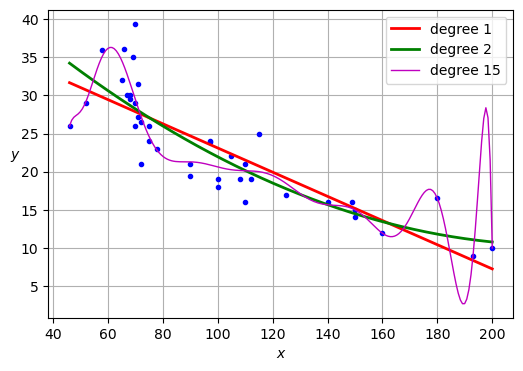

In [33]:
X_small = df_small[['horsepower']]
y_small = df_small[['mpg']]

X_new = np.linspace(X_small.min(), X_small.max() , 200).reshape(-1,1)

plt.figure(figsize=(6, 4))
plt.plot(X_small, y_small, "b.")

for degree, style, width in [(1, "r-", 2), (2, "g-", 2), (15, "m-", 1)]:

    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X_small)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_poly)

    lin_reg = LinearRegression()
    lin_reg.fit(X_scaled, y_small)

    X_new_poly = poly_features.transform(X_new)
    X_new_scaled = scaler.transform(X_new_poly)
    y_pred = lin_reg.predict(X_new_scaled)

    plt.plot(X_new, y_pred, style, linewidth=width, label=f"degree {degree}")

plt.xlabel("$x$"); plt.ylabel("$y$", rotation=0)
plt.legend(); plt.grid()
plt.show()

In [54]:
## RMSE on the 40 Training Cars

degrees = [1, 2, 15]
rmse_list = {}
for i in degrees:
    poly=PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(X_small)

    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y_small) 
    
    y_predicted = lin_reg.predict(X_poly)
    rmse = root_mean_squared_error(y_small, y_predicted)
    rmse_list[i] = rmse

df_rmse_list = pd.DataFrame.from_dict(rmse_list, orient='index', columns=["40 TRAINING CARS RMSE"]).rename_axis('DEGREE').reset_index()
df_rmse_list

,DEGREE,40 TRAINING CARS RMSE
0,1,3.939361
1,2,3.748668
2,15,4.143372


In [57]:
## RMSE on the test set

degrees = [1, 2, 15]
rmse_list = {}
for i in degrees:
    poly=PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(X_test)

    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y_test) 
    
    y_predicted = lin_reg.predict(X_poly)
    rmse = root_mean_squared_error(y_test, y_predicted)
    rmse_list[i] = rmse

df_rmse_list = pd.DataFrame.from_dict(rmse_list, orient='index', columns=["TEST SET RMSE"]).rename_axis('DEGREE').reset_index()
df_rmse_list

,DEGREE,TEST SET RMSE
0,1,4.543415
1,2,4.116980
2,15,4.719318


**5a.** Refit the straight line and degrees 2, 5, and 15 on just those 40 cars, and plot them on top of the 40 points.

**5b.** Report **two** numbers for each degree: RMSE on the 40 training cars, and RMSE on the test set.

**5c.** What happened to degree 15? Describe the size of the difference between its two numbers.

**5d.** Go back to what you wrote in 4f. Were you right? Now answer it properly: **overfitting is not really about the degree. What is it about?**

*Your answers here.*

---

# Part 6: Learning curves explain it

**6a.** Plot learning curves for the degree 15 model on the **full** training set. You can reuse `plot_learning_curve` from the Day 2 notes.

**6b.** Look at the **left** edge, where the training set is small. Does it match what you found in Part 5?

**6c.** Look at the **right** edge. Have the curves flattened out, or is the validation curve still coming down?

**6d.** Based only on that plot: if someone offered you data on another 400 cars, would it be worth having? Why?

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


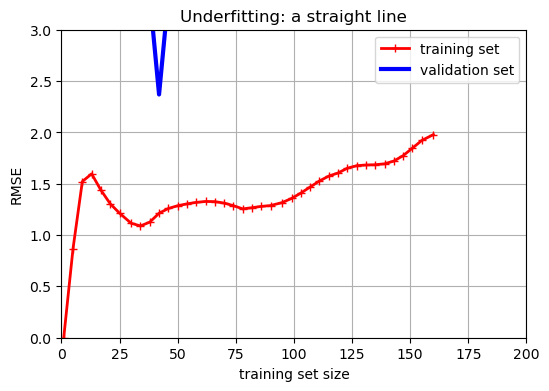

In [62]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline

poly_features = PolynomialFeatures(degree=15, include_bias=False)
X_poly = poly_features.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

X_new_poly = poly_features.transform(X_new)
X_new_scaled = scaler.transform(X_new_poly)
y_pred = lin_reg.predict(X_new_scaled)

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        model, X, y.ravel(), train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
        scoring="neg_root_mean_squared_error")
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)

    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="training set")
    plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="validation set")
    plt.xlabel("training set size"); plt.ylabel("RMSE")
    plt.title(title); plt.legend(); plt.grid(); plt.axis([0, 200, 0, 3])
    plt.show()

# the straight line from earlier
lin_model = LinearRegression()

plot_learning_curve(lin_model, X_new, y_pred, "Underfitting: a straight line")

*Your answers here.*

---

# Part 7: The test set, once

Every decision so far was made on the training set. Time to commit.

**7a.** Pick the degree you think is best for the **full** training set and say why, **before** you touch the test set.

**7b.** Now evaluate that one model on the test set. Report the test RMSE.

**7c.** How does it compare to the training RMSE for the same model? Is that what you expected?

**7d.** Suppose the test RMSE came out worse than you hoped. Are you allowed to go back, pick a different degree, and report that instead? Why or why not?

In [ ]:
# your code here


*Your answers here.*

---

# Part 8: What does it actually mean

**8a.** In two or three sentences with no equations: how well can you predict fuel economy from horsepower alone? Would you trust this model?

**8b.** Your best RMSE is probably somewhere around 4. **Is that good?** What would you need to know to answer that properly?

**8c.** This data is cars from 1970 to 1982. Someone wants to use your model on a 2026 electric vehicle. What do you tell them?

**8d.** Suppose a manufacturer used a model like this to advertise fuel economy to customers. What would it mean for the model to be wrong, and who would pay for it?

*Your answers here.*

---

**8e.** What is the one thing in this assignment you did not expect? A short paragraph.

*Your answer here.*